## IMPORTS

In [1]:
import scanpy as sc
import numpy as np
from scipy.stats import median_abs_deviation    
import scrublet as scr
# Vizualisation settings
sc.set_figure_params(dpi=100, frameon=False, vector_friendly=True)

### Obtaining data

In [ ]:
import os

if not os.path.exists('../data/cellxgene.h5ad'):
    os.makedirs('../data', exist_ok=True)
    os.system('wget -c --progress=bar https://datasets.cellxgene.cziscience.com/a95f7e58-a8fb-4fcd-b55f-e074cdae155b.h5ad -O ../data/cellxgene.h5ad')

In [2]:
adata = sc.read_h5ad('../data/cellxgene.h5ad')
adata.layers['counts'] = adata.X.copy()
print(adata)
print("var index name:", adata.var.index.name)
print("var columns:", adata.var.columns.tolist()[:5])

AnnData object with n_obs × n_vars = 117266 × 57398
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts'
var index name: ensembl_id
var columns: ['gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype']


## QC

### Change gene names to proper format

In [3]:
from collections import Counter

adata.var['ensembl_id'] = adata.var_names.astype(str)

gene_names = adata.var['gene_symbol'].astype(str).values.tolist()
ensembl = adata.var['ensembl_id'].values.tolist()

gene_names = [e if g == 'nan' else g for g, e in zip(gene_names, ensembl)]

counts = Counter()
unique_names = []
for name in gene_names:
    counts[name] += 1
    unique_names.append(f"{name}-{counts[name]}" if counts[name] > 1 else name)

adata.var_names = unique_names
adata.var.index.name = None
print("Done:", adata.var_names[:3].tolist())
print(f"Genes total: {adata.n_vars}")

Done: ['LINC01409', 'FAM87B', 'LINC01128']
Genes total: 57398


### Cell type manual annotation

In [4]:
cell_map = {
    'epithelial cell of lung': 'Tumor',
    'fibroblast of lung': 'Stroma', 'lung pericyte': 'Stroma',
    'endothelial cell': 'Stroma',
    'macrophage': 'Myeloid', 'lung macrophage': 'Myeloid',
    'CD14-positive monocyte': 'Myeloid',
    'CD14-positive, CD16-positive monocyte': 'Myeloid',
    'cycling mononuclear phagocyte': 'Myeloid',
    'neutrophil': 'Myeloid', 'conventional dendritic cell': 'Myeloid',
    'plasmacytoid dendritic cell': 'Myeloid',
    'CD141-positive myeloid dendritic cell': 'Myeloid',
    'mast cell': 'Myeloid', 'innate lymphoid cell': 'Myeloid',
    'B cell': 'Lymphoid', 'plasma cell': 'Lymphoid',
    'CD38-positive naive B cell': 'Lymphoid',
    'naive thymus-derived CD4-positive, alpha-beta T cell': 'Lymphoid',
    'CD4-positive, CD25-positive, alpha-beta regulatory T cell': 'Lymphoid',
    'CD4-positive, alpha-beta T cell': 'Lymphoid',
    'CD8-positive, alpha-beta T cell': 'Lymphoid',
    'activated CD4-positive, alpha-beta T cell, human': 'Lymphoid',
    'naive thymus-derived CD8-positive, alpha-beta T cell': 'Lymphoid',
    'CD8-positive, alpha-beta cytotoxic T cell': 'Lymphoid',
    'natural killer cell': 'Lymphoid',
    'gamma-delta T cell': 'Lymphoid', 'lymphocyte': 'Lymphoid',
    'mature NK T cell': 'Lymphoid',
    'CD4-positive type I NK T cell secreting interferon-gamma': 'Lymphoid',
}
adata.obs['cell_group'] = adata.obs['cell_type'].map(cell_map)
print("cell_group:", adata.obs['cell_group'].value_counts().to_dict())

cell_group: {'Lymphoid': 50206, 'Tumor': 37048, 'Myeloid': 25583, 'Stroma': 4429}


### QC + Metrics

In [5]:
# Remove mitochondrial ,ribosomal and hemoglobin genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=["mt", "ribo", "hb"], 
    inplace=True, 
    percent_top=[20], 
    log1p=True
)

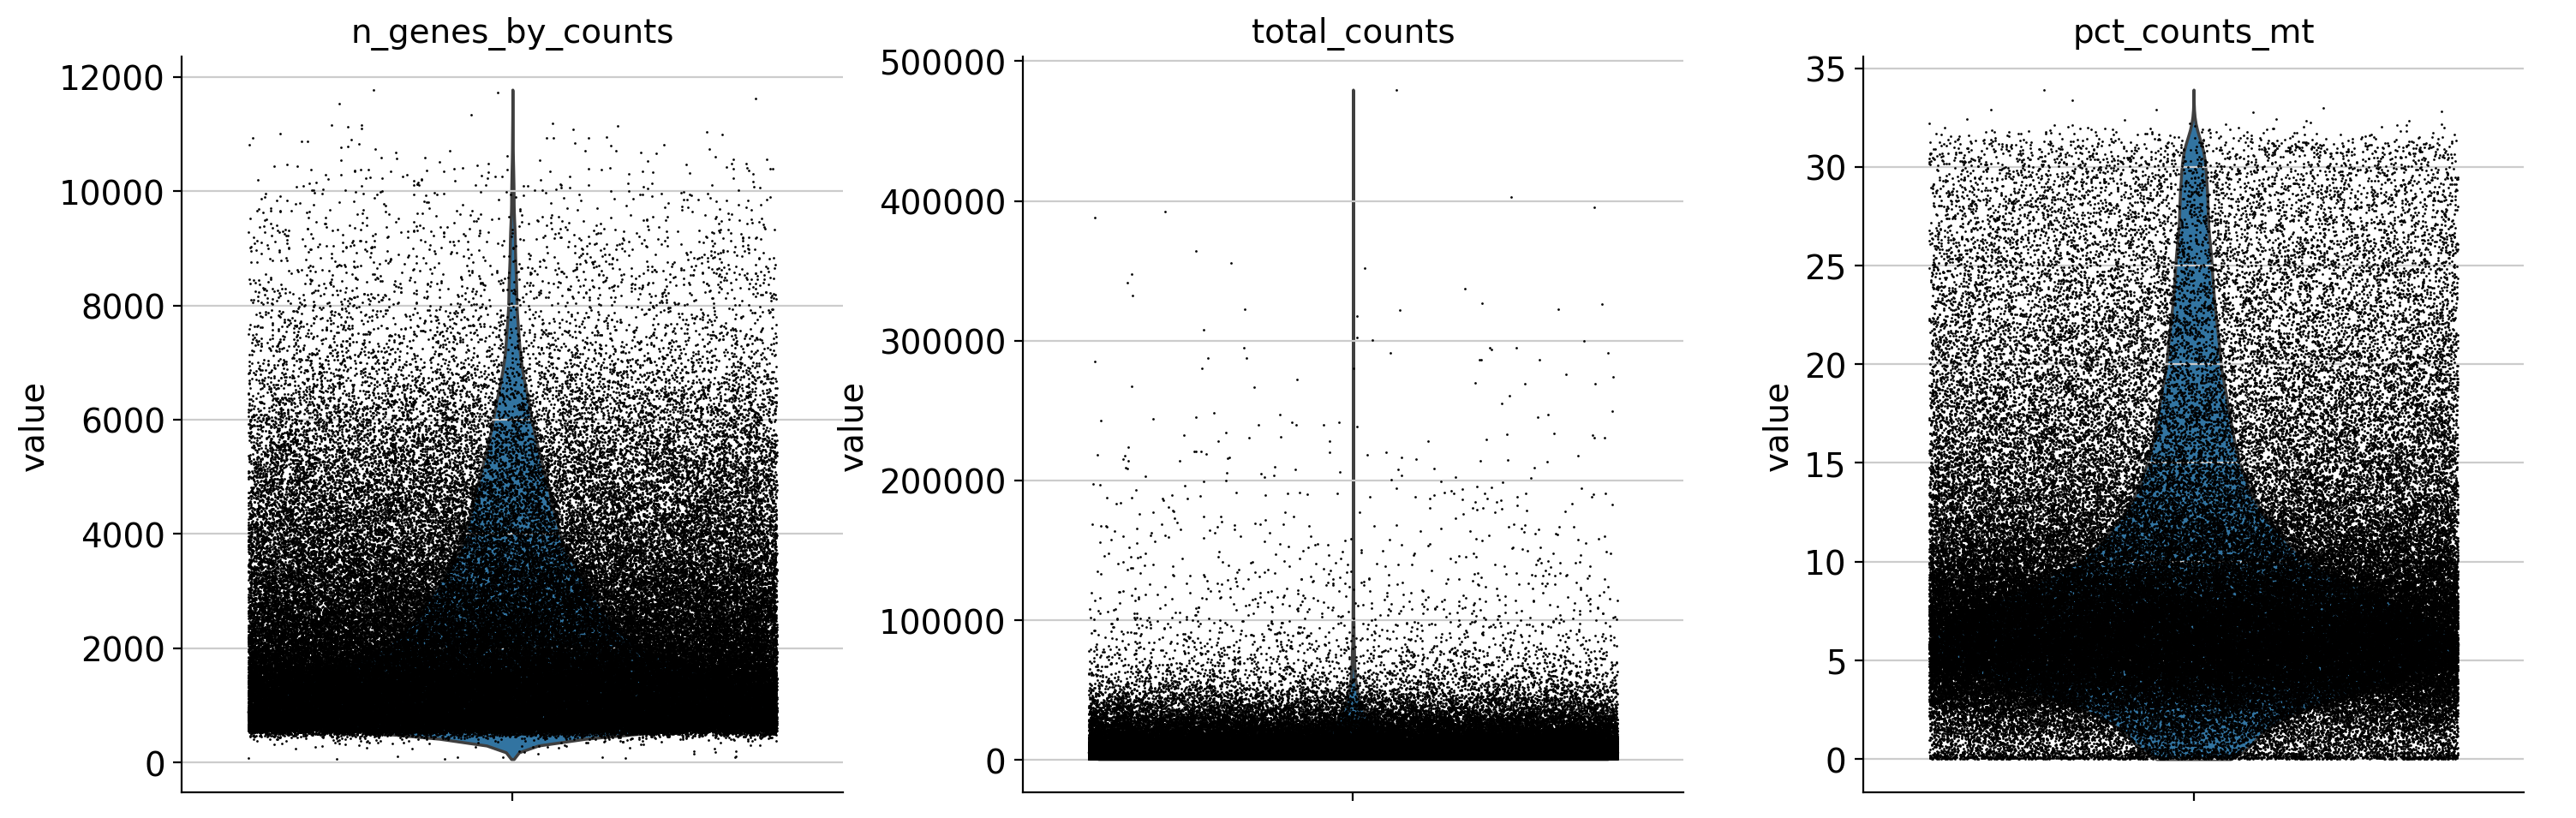

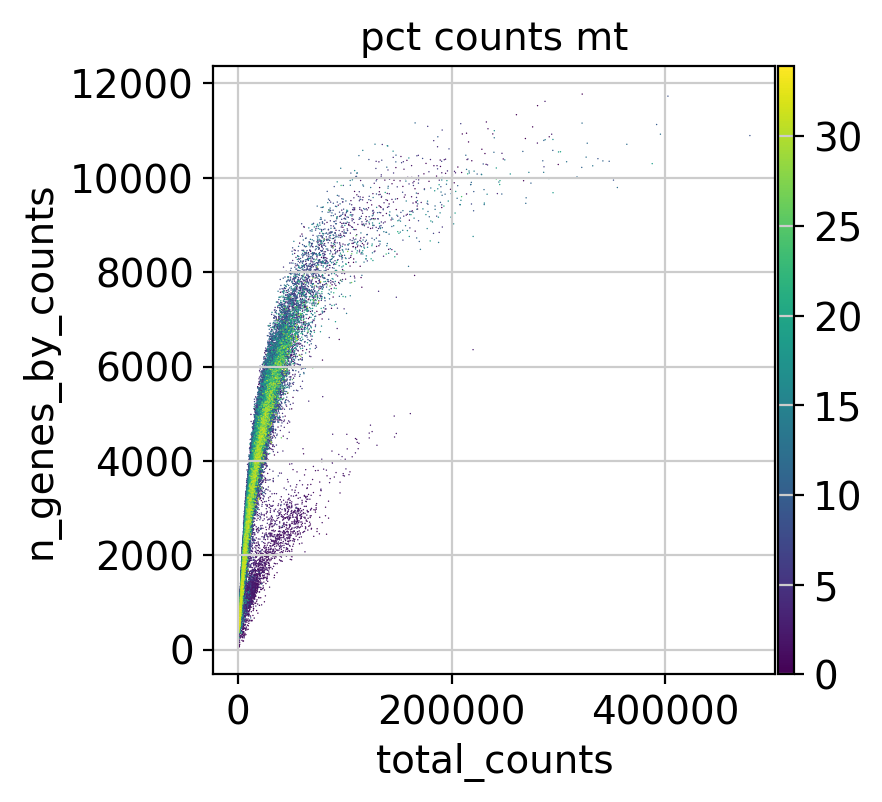

In [6]:
sc.pl.violin(
    adata, 
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"], 
    jitter=0.4, 
    multi_panel=True
)

sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### Outliers

In [7]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5) | 
    is_outlier(adata, "log1p_n_genes_by_counts", 5)
)

adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] > 15)

print(f"General outliers found: {adata.obs.outlier.sum()}")
print(f"Mt outliers found: {adata.obs.mt_outlier.sum()}")

General outliers found: 100
Mt outliers found: 18207


In [8]:
scrub = scr.Scrublet(adata.X)
doublet_scores, predicted_doublets = scrub.scrub_doublets()

adata.obs["doublet_score"] = doublet_scores
adata.obs["is_doublet"] = predicted_doublets

print(f"Potential doublets found: {adata.obs.is_doublet.sum()}")

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Elapsed time: 377.8 seconds
Potential doublets found: 0


In [9]:
adata.obs['outlier'] = adata.obs['outlier'].fillna(False).astype(bool)
adata.obs['mt_outlier'] = adata.obs['mt_outlier'].fillna(False).astype(bool)
adata.obs['is_doublet'] = adata.obs['is_doublet'].fillna(False).astype(bool)

n_cells_before = adata.n_obs

adata = adata[~adata.obs.outlier & ~adata.obs.mt_outlier & ~adata.obs.is_doublet].copy()

sc.pp.filter_genes(adata, min_cells=20)

print(f"Cells removed: {n_cells_before - adata.n_obs}")
print(f"Cells left: {adata.n_obs}")
print(f"Genes left: {adata.n_vars}")    

/tmp/ipykernel_259057/2921388441.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs['is_doublet'] = adata.obs['is_doublet'].fillna(False).astype(bool)


Cells removed: 18290
Cells left: 98976
Genes left: 19027


### Log-normalisation

In [10]:
adata.raw = adata
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Write adata

In [11]:
adata.write_h5ad("../data/adata_qc.h5ad")